In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/anikannal/solar-power-generation-data/Plant_2_Generation_Data.csv
/kaggle/input/datasets/anikannal/solar-power-generation-data/Plant_2_Weather_Sensor_Data.csv
/kaggle/input/datasets/anikannal/solar-power-generation-data/Plant_1_Weather_Sensor_Data.csv
/kaggle/input/datasets/anikannal/solar-power-generation-data/Plant_1_Generation_Data.csv


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import IsolationForest
from xgboost import XGBRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib, os, warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3
COLORS = ['#2196F3', '#FF5722', '#4CAF50', '#FF9800', '#9C27B0']

print('Libraries loaded')

Libraries loaded


In [4]:
BASE = '/kaggle/input/datasets/anikannal/solar-power-generation-data/'

gen1     = pd.read_csv(BASE + 'Plant_1_Generation_Data.csv')
gen2     = pd.read_csv(BASE + 'Plant_2_Generation_Data.csv')
weather1 = pd.read_csv(BASE + 'Plant_1_Weather_Sensor_Data.csv')
weather2 = pd.read_csv(BASE + 'Plant_2_Weather_Sensor_Data.csv')

gen1['PLANT_ID_LABEL']     = 'Plant_1'
gen2['PLANT_ID_LABEL']     = 'Plant_2'
weather1['PLANT_ID_LABEL'] = 'Plant_1'
weather2['PLANT_ID_LABEL'] = 'Plant_2'

print(f'Plant 1 Generation:  {gen1.shape[0]:,} rows × {gen1.shape[1]} cols')
print(f'Plant 2 Generation:  {gen2.shape[0]:,} rows × {gen2.shape[1]} cols')
print(f'Plant 1 Weather:     {weather1.shape[0]:,} rows × {weather1.shape[1]} cols')
print(f'Plant 2 Weather:     {weather2.shape[0]:,} rows × {weather2.shape[1]} cols')

Plant 1 Generation:  68,778 rows × 8 cols
Plant 2 Generation:  67,698 rows × 8 cols
Plant 1 Weather:     3,182 rows × 7 cols
Plant 2 Weather:     3,259 rows × 7 cols


In [5]:
print('=== Generation Data (Plant 1) ===')
display(gen1.head())
print('\nColumns:', list(gen1.columns))

print('\n=== Weather Data (Plant 1) ===')
display(weather1.head())

print('\n=== Statistical Summary — Generation ===')
display(gen1[['DC_POWER','AC_POWER','DAILY_YIELD','TOTAL_YIELD']].describe().round(2))

print('\n=== Statistical Summary — Weather ===')
display(weather1[['AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','IRRADIATION']].describe().round(2))

=== Generation Data (Plant 1) ===


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_LABEL
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,Plant_1
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,Plant_1
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,Plant_1
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,Plant_1
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,Plant_1



Columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'PLANT_ID_LABEL']

=== Weather Data (Plant 1) ===


,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION,PLANT_ID_LABEL
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0,Plant_1
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0,Plant_1
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0,Plant_1
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0,Plant_1
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0,Plant_1



=== Statistical Summary — Generation ===


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,68778.00,68778.00,68778.00,68778.00
mean,3147.43,307.80,3295.97,6978711.76
std,4036.46,394.40,3145.18,416271.98
min,0.00,0.00,0.00,6183645.00
25%,0.00,0.00,0.00,6512002.54
50%,429.00,41.49,2658.71,7146685.00
75%,6366.96,623.62,6274.00,7268705.91
max,14471.12,1410.95,9163.00,7846821.00



=== Statistical Summary — Weather ===


,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,3182.00,3182.00,3182.00
mean,25.53,31.09,0.23
std,3.35,12.26,0.30
min,20.40,18.14,0.00
25%,22.71,21.09,0.00
50%,24.61,24.62,0.02
75%,27.92,41.31,0.45
max,35.25,65.55,1.22


In [6]:
print('Gen1 columns:    ', list(gen1.columns))
print('Weather1 columns:', list(weather1.columns))

Gen1 columns:     ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'PLANT_ID_LABEL']
Weather1 columns: ['DATE_TIME', 'PLANT_ID', 'SOURCE_KEY', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'PLANT_ID_LABEL']


In [7]:
print('Gen1 SOURCE_KEY sample:    ', gen1['SOURCE_KEY'].unique()[:3])
print('Weather1 SOURCE_KEY sample:', weather1['SOURCE_KEY'].unique()[:3])
print()
print('Gen1 DATE_TIME sample:    ', gen1['DATE_TIME'].head(3).tolist())
print('Weather1 DATE_TIME sample:', weather1['DATE_TIME'].head(3).tolist())

Gen1 SOURCE_KEY sample:     ['1BY6WEcLGh8j5v7' '1IF53ai7Xc0U56Y' '3PZuoBAID5Wc2HD']
Weather1 SOURCE_KEY sample: ['HmiyD2TTLFNqkNe']

Gen1 DATE_TIME sample:     ['15-05-2020 00:00', '15-05-2020 00:00', '15-05-2020 00:00']
Weather1 DATE_TIME sample: ['2020-05-15 00:00:00', '2020-05-15 00:15:00', '2020-05-15 00:30:00']


In [8]:
for frame in [gen1, gen2, weather1, weather2]:
    frame['DATE_TIME'] = pd.to_datetime(frame['DATE_TIME'], dayfirst=True)

# Weather مفيهاش SOURCE_KEY مفيد — نشيله قبل الـ merge
w1 = weather1.drop(columns=['SOURCE_KEY'])
w2 = weather2.drop(columns=['SOURCE_KEY'])

# Merge على DATE_TIME + PLANT_ID + PLANT_ID_LABEL بس
plant1 = pd.merge(gen1, w1, on=['DATE_TIME','PLANT_ID','PLANT_ID_LABEL'], how='left')
plant2 = pd.merge(gen2, w2, on=['DATE_TIME','PLANT_ID','PLANT_ID_LABEL'], how='left')

df = pd.concat([plant1, plant2], ignore_index=True)
df.sort_values('DATE_TIME', inplace=True)
df.reset_index(drop=True, inplace=True)

print(f'Merged shape: {df.shape[0]:,} rows × {df.shape[1]} cols')
print('Missing values:\n', df.isnull().sum()[df.isnull().sum() > 0])
display(df.head())

Merged shape: 136,476 rows × 11 cols
Missing values:
 AMBIENT_TEMPERATURE    4
MODULE_TEMPERATURE     4
IRRADIATION            4
dtype: int64


,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_LABEL,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.000000,6.259559e+06,Plant_1,25.184316,22.857507,0.0
1,2020-05-15,4136001,Et9kgGMDl729KT4,0.0,0.0,269.933333,1.704250e+06,Plant_2,27.004764,25.060789,0.0
2,2020-05-15,4136001,IQ2d7wF4YD8zU1Q,0.0,0.0,3177.000000,1.994153e+07,Plant_2,27.004764,25.060789,0.0
3,2020-05-15,4136001,LYwnQax7tkwH5Cb,0.0,0.0,1872.500000,1.794959e+09,Plant_2,27.004764,25.060789,0.0
4,2020-05-15,4136001,LlT2YUhhzqhg5Sw,0.0,0.0,1094.357143,2.825928e+08,Plant_2,27.004764,25.060789,0.0


In [9]:
df.ffill(inplace=True)
df.bfill(inplace=True)

# Time features
df['HOUR']        = df['DATE_TIME'].dt.hour
df['DAY']         = df['DATE_TIME'].dt.day
df['MONTH']       = df['DATE_TIME'].dt.month
df['DAY_OF_WEEK'] = df['DATE_TIME'].dt.dayofweek
df['IS_WEEKEND']  = df['DAY_OF_WEEK'].isin([5, 6]).astype(int)

# Cyclical encoding
df['HOUR_SIN']  = np.sin(2 * np.pi * df['HOUR']  / 24)
df['HOUR_COS']  = np.cos(2 * np.pi * df['HOUR']  / 24)
df['MONTH_SIN'] = np.sin(2 * np.pi * df['MONTH'] / 12)
df['MONTH_COS'] = np.cos(2 * np.pi * df['MONTH'] / 12)

# Physical features
df['TEMP_DIFF']        = df['MODULE_TEMPERATURE'] - df['AMBIENT_TEMPERATURE']
df['POWER_EFFICIENCY'] = np.where(
    df['IRRADIATION'] > 0,
    df['AC_POWER'] / (df['IRRADIATION'] + 1e-9),
    0
)

# Lag features — grouped by SOURCE_KEY (inverter level)
df = df.sort_values('DATE_TIME')
for lag in [1, 2, 3]:
    df[f'AC_POWER_LAG{lag}'] = df.groupby('SOURCE_KEY')['AC_POWER'].shift(lag)
df['AC_POWER_ROLL3'] = df.groupby('SOURCE_KEY')['AC_POWER'].transform(
    lambda x: x.rolling(3, min_periods=1).mean()
)
df.fillna(0, inplace=True)

print(f'Features after engineering: {df.shape[1]} columns')
print('Missing values after fill:', df.isnull().sum().sum())

Features after engineering: 26 columns
Missing values after fill: 0


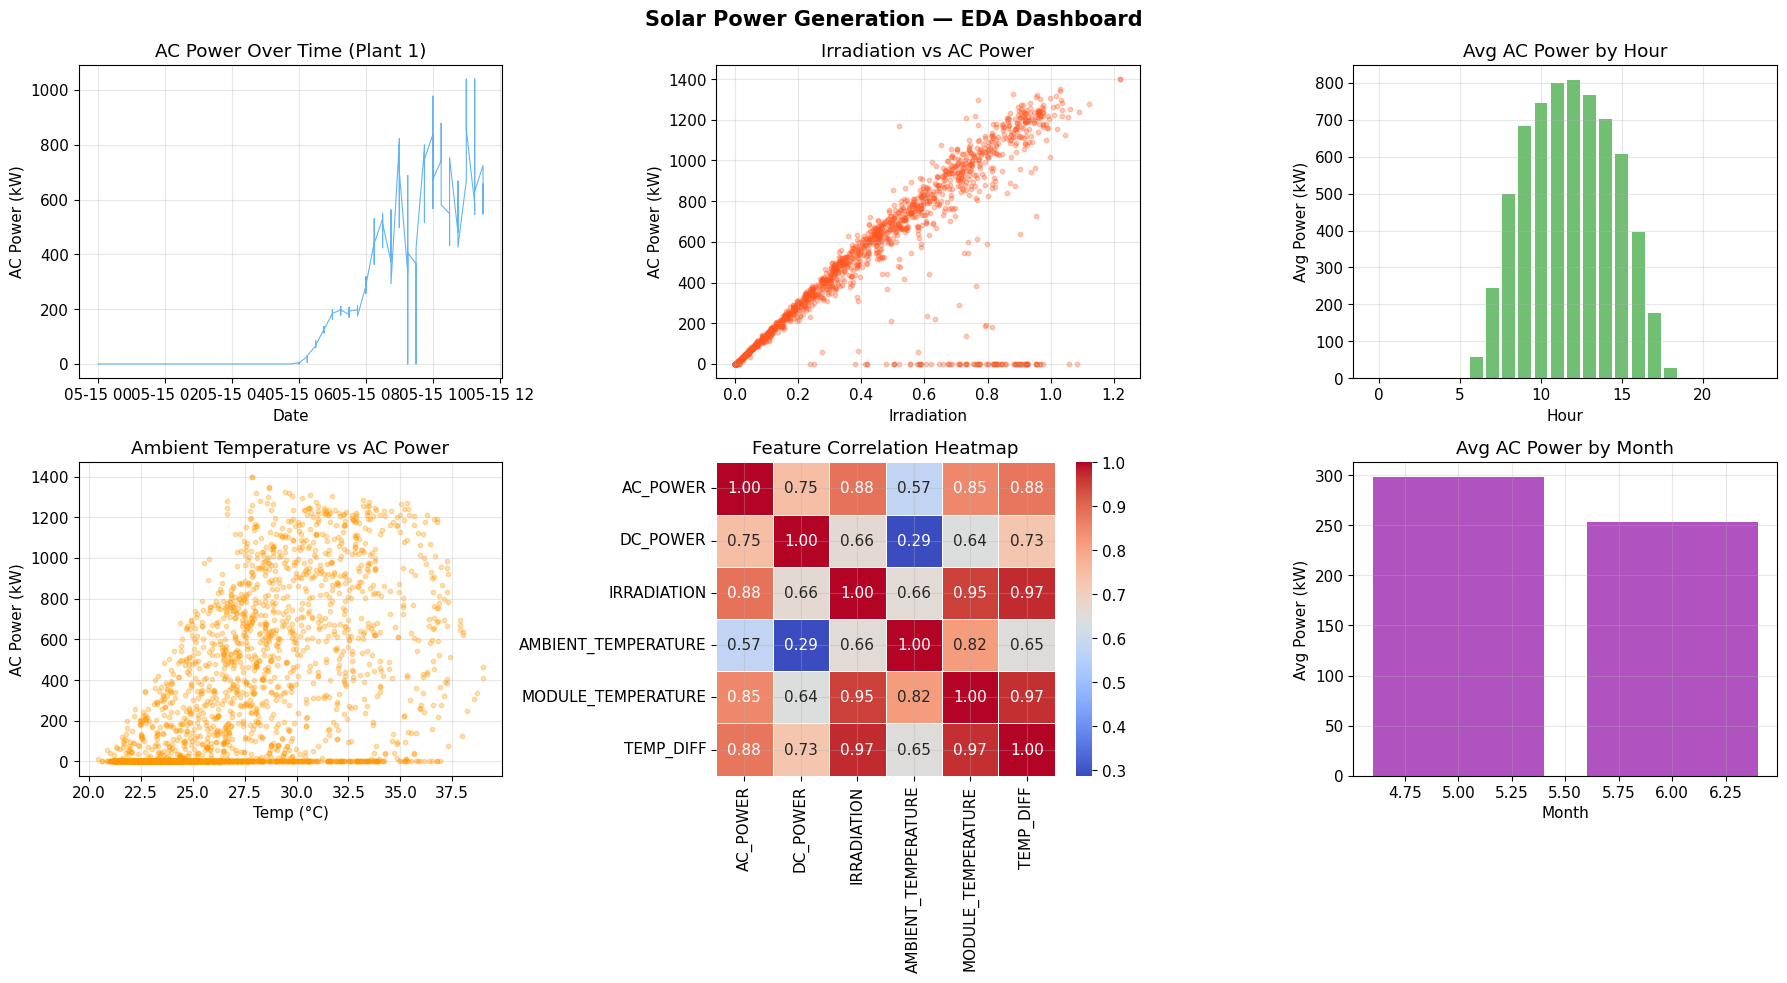

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Solar Power Generation — EDA Dashboard', fontsize=15, fontweight='bold')

# 1. AC Power over time
p1 = df[df['PLANT_ID_LABEL'] == 'Plant_1'].head(1000)
axes[0,0].plot(p1['DATE_TIME'], p1['AC_POWER'], color=COLORS[0], alpha=0.7, linewidth=0.8)
axes[0,0].set_title('AC Power Over Time (Plant 1)')
axes[0,0].set_xlabel('Date'); axes[0,0].set_ylabel('AC Power (kW)')

# 2. Irradiation vs AC Power
s = df.sample(min(3000, len(df)), random_state=42)
axes[0,1].scatter(s['IRRADIATION'], s['AC_POWER'], alpha=0.3, color=COLORS[1], s=10)
axes[0,1].set_title('Irradiation vs AC Power')
axes[0,1].set_xlabel('Irradiation'); axes[0,1].set_ylabel('AC Power (kW)')

# 3. Avg power by hour
hourly = df.groupby('HOUR')['AC_POWER'].mean()
axes[0,2].bar(hourly.index, hourly.values, color=COLORS[2], alpha=0.8)
axes[0,2].set_title('Avg AC Power by Hour')
axes[0,2].set_xlabel('Hour'); axes[0,2].set_ylabel('Avg Power (kW)')

# 4. Temperature vs AC Power
axes[1,0].scatter(s['AMBIENT_TEMPERATURE'], s['AC_POWER'], alpha=0.3, color=COLORS[3], s=10)
axes[1,0].set_title('Ambient Temperature vs AC Power')
axes[1,0].set_xlabel('Temp (°C)'); axes[1,0].set_ylabel('AC Power (kW)')

# 5. Correlation heatmap
corr_cols = ['AC_POWER','DC_POWER','IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE','TEMP_DIFF']
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm',
            ax=axes[1,1], linewidths=0.5)
axes[1,1].set_title('Feature Correlation Heatmap')

# 6. Monthly avg
monthly = df.groupby('MONTH')['AC_POWER'].mean()
axes[1,2].bar(monthly.index, monthly.values, color=COLORS[4], alpha=0.8)
axes[1,2].set_title('Avg AC Power by Month')
axes[1,2].set_xlabel('Month'); axes[1,2].set_ylabel('Avg Power (kW)')

plt.tight_layout()
plt.show()

In [11]:
FEATURES = [
    'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
    'HOUR', 'DAY', 'MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND',
    'HOUR_SIN', 'HOUR_COS', 'MONTH_SIN', 'MONTH_COS',
    'TEMP_DIFF', 'POWER_EFFICIENCY',
    'AC_POWER_LAG1', 'AC_POWER_LAG2', 'AC_POWER_LAG3', 'AC_POWER_ROLL3'
]
TARGET = 'AC_POWER'

df_model = df[FEATURES + [TARGET, 'DATE_TIME']].dropna()
X = df_model[FEATURES]
y = df_model[TARGET]
dates = df_model['DATE_TIME']


split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
dates_train     = dates.iloc[:split_idx]
dates_test      = dates.iloc[split_idx:]

# Scaling
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_sc = scaler_X.fit_transform(X_train)
X_test_sc  = scaler_X.transform(X_test)
y_train_sc = scaler_y.fit_transform(y_train.values.reshape(-1,1)).ravel()
y_test_sc  = scaler_y.transform(y_test.values.reshape(-1,1)).ravel()

print(f'Features:     {len(FEATURES)}')
print(f'Train:        {len(X_train):,} samples  ({dates_train.min().date()} → {dates_train.max().date()})')
print(f'Test:         {len(X_test):,} samples   ({dates_test.min().date()} → {dates_test.max().date()})')
print(f'Target range: {y.min():.1f} → {y.max():.1f} kW')

Features:     18
Train:        109,180 samples  (2020-05-15 → 2020-06-11)
Test:         27,296 samples   (2020-06-11 → 2020-06-17)
Target range: 0.0 → 1411.0 kW


In [12]:
os.makedirs('/kaggle/working/output', exist_ok=True)

df.to_csv('/kaggle/working/output/solar_processed.csv', index=False)
joblib.dump(scaler_X, '/kaggle/working/output/scaler_X.pkl')
joblib.dump(scaler_y, '/kaggle/working/output/scaler_y.pkl')

print('Saved: solar_processed.csv')
print('Saved: scaler_X.pkl')
print('Saved: scaler_y.pkl')

print('\n' + '='*50)
print('  Phase 1 Complete!')
print('='*50)
print(f'  Total records:  {len(df):,}')
print(f'  Date range:     {df["DATE_TIME"].min().date()} → {df["DATE_TIME"].max().date()}')
print(f'  Inverters:      {df["SOURCE_KEY"].nunique()}')
print(f'  Plants:         2')
print(f'  Train/Test:     {len(X_train):,} / {len(X_test):,}')
print('='*50)

Saved: solar_processed.csv
Saved: scaler_X.pkl
Saved: scaler_y.pkl

  Phase 1 Complete!
  Total records:  136,476
  Date range:     2020-05-15 → 2020-06-17
  Inverters:      44
  Plants:         2
  Train/Test:     109,180 / 27,296


In [13]:
FEATURES = [
    'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
    'HOUR', 'DAY', 'MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND',
    'HOUR_SIN', 'HOUR_COS', 'MONTH_SIN', 'MONTH_COS',
    'TEMP_DIFF', 'POWER_EFFICIENCY',
    'AC_POWER_LAG1', 'AC_POWER_LAG2', 'AC_POWER_LAG3', 'AC_POWER_ROLL3'
]
TARGET = 'AC_POWER'

df_model = df[FEATURES + [TARGET, 'DATE_TIME']].dropna()
X     = df_model[FEATURES]
y     = df_model[TARGET]
dates = df_model['DATE_TIME']

print(f'Features: {len(FEATURES)}')
print(f'Samples:  {len(X):,}')
print(f'Target range: {y.min():.2f} → {y.max():.2f} kW')

Features: 18
Samples:  136,476
Target range: 0.00 → 1410.95 kW


In [14]:
split_idx = int(len(X) * 0.8)

X_train = X.iloc[:split_idx]
X_test  = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test  = y.iloc[split_idx:]
dates_train = dates.iloc[:split_idx]
dates_test  = dates.iloc[split_idx:]

print(f'Train: {len(X_train):,} samples  ({dates_train.min().date()} → {dates_train.max().date()})')
print(f'Test:  {len(X_test):,} samples   ({dates_test.min().date()} → {dates_test.max().date()})')

Train: 109,180 samples  (2020-05-15 → 2020-06-11)
Test:  27,296 samples   (2020-06-11 → 2020-06-17)


In [15]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

print('Training...')
rf_model.fit(X_train, y_train)
print('Done')

Training...
Done


In [16]:
y_pred_train = rf_model.predict(X_train)
y_pred_test  = rf_model.predict(X_test)

def evaluate(y_true, y_pred, label):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-9))) * 100
    print(f'── {label} ──')
    print(f'  MAE  : {mae:.4f} kW')
    print(f'  RMSE : {rmse:.4f} kW')
    print(f'  R²   : {r2:.4f}')
    print(f'  MAPE : {mape:.2f}%')
    return {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

train_metrics = evaluate(y_train, y_pred_train, 'Train')
print()
test_metrics  = evaluate(y_test, y_pred_test, 'Test')

── Train ──
  MAE  : 2.7012 kW
  RMSE : 7.3078 kW
  R²   : 0.9997
  MAPE : 10518551785.57%

── Test ──
  MAE  : 11.5236 kW
  RMSE : 25.2565 kW
  R²   : 0.9941
  MAPE : 33652824438.58%


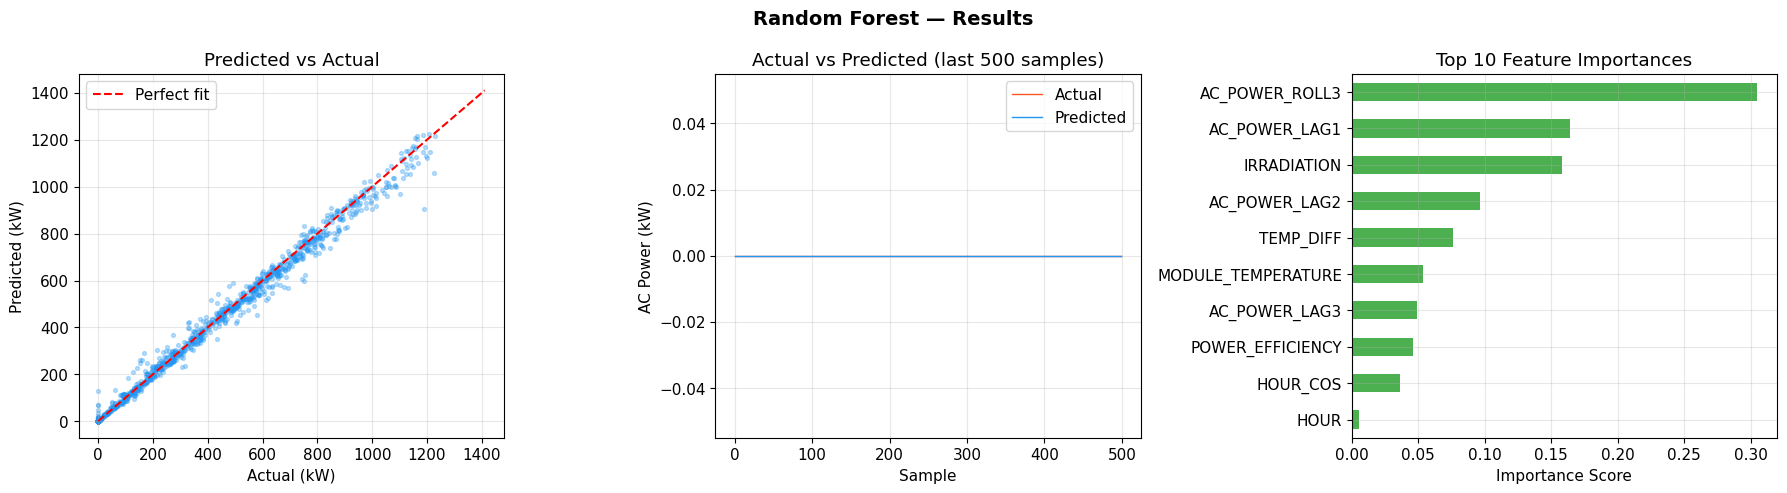

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Random Forest — Results', fontsize=14, fontweight='bold')

# Predicted vs Actual
sample_idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_pred_test[sample_idx],
                alpha=0.3, s=8, color='#2196F3')
max_val = max(y_test.max(), y_pred_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual (kW)')
axes[0].set_ylabel('Predicted (kW)')
axes[0].legend()

# Time series
n = 500
axes[1].plot(range(n), y_test.values[-n:], label='Actual', color='#FF5722', linewidth=1)
axes[1].plot(range(n), y_pred_test[-n:],   label='Predicted', color='#2196F3', linewidth=1)
axes[1].set_title('Actual vs Predicted (last 500 samples)')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('AC Power (kW)')
axes[1].legend()

# Feature Importance
importances = pd.Series(rf_model.feature_importances_, index=FEATURES)
importances.sort_values(ascending=True).tail(10).plot(kind='barh', ax=axes[2], color='#4CAF50')
axes[2].set_title('Top 10 Feature Importances')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()

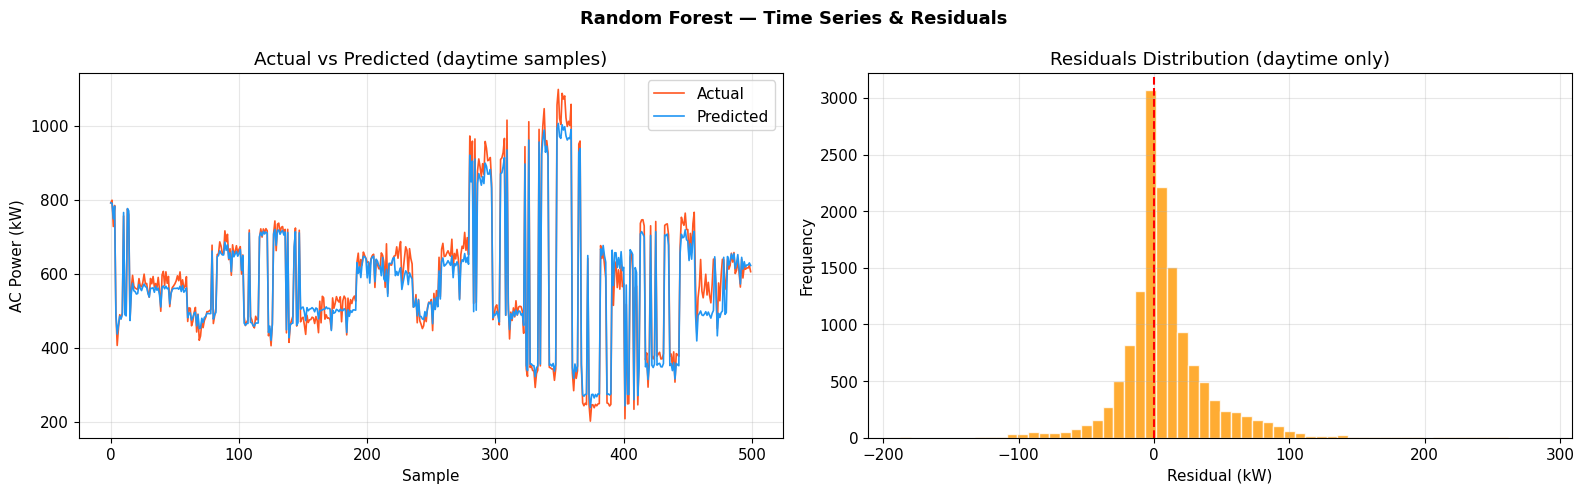

Model saved
        Model      MAE      RMSE       R2
Random Forest 11.52356 25.256527 0.994092


In [18]:
daytime_mask = y_test.values > 0
daytime_idx  = np.where(daytime_mask)[0]
start        = daytime_idx[0]
end          = min(start + 500, len(y_test))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Random Forest — Time Series & Residuals', fontsize=13, fontweight='bold')

# Time series
axes[0].plot(range(end - start), y_test.values[start:end],
             label='Actual', color='#FF5722', linewidth=1.2)
axes[0].plot(range(end - start), y_pred_test[start:end],
             label='Predicted', color='#2196F3', linewidth=1.2)
axes[0].set_title('Actual vs Predicted (daytime samples)')
axes[0].set_xlabel('Sample')
axes[0].set_ylabel('AC Power (kW)')
axes[0].legend()

# Residuals distribution 
residuals = y_test.values[daytime_mask] - y_pred_test[daytime_mask]
axes[1].hist(residuals, bins=60, color='#FF9800', alpha=0.8, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals Distribution (daytime only)')
axes[1].set_xlabel('Residual (kW)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()


import joblib, os
os.makedirs('/kaggle/working/output', exist_ok=True)
joblib.dump(rf_model, '/kaggle/working/output/rf_model.pkl')


results_rf = pd.DataFrame({
    'Model'  : ['Random Forest'],
    'MAE'    : [test_metrics['MAE']],
    'RMSE'   : [test_metrics['RMSE']],
    'R2'     : [test_metrics['R2']]
})
results_rf.to_csv('/kaggle/working/output/model_comparison.csv', index=False)
print('Model saved')
print(results_rf.to_string(index=False))

In [19]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    tree_method='hist'
)

print('Training XGBoost...')
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)
print('Done')

Training XGBoost...
[0]	validation_0-rmse:315.13318
[100]	validation_0-rmse:10.23572
[200]	validation_0-rmse:8.48832
[300]	validation_0-rmse:8.24890
[400]	validation_0-rmse:8.11772
[499]	validation_0-rmse:8.02341
Done


In [20]:
y_pred_xgb_train = xgb_model.predict(X_train)
y_pred_xgb_test  = xgb_model.predict(X_test)

xgb_train_metrics = evaluate(y_train, y_pred_xgb_train, 'XGBoost Train')
print()
xgb_test_metrics  = evaluate(y_test, y_pred_xgb_test, 'XGBoost Test')

── XGBoost Train ──
  MAE  : 1.0407 kW
  RMSE : 2.0721 kW
  R²   : 1.0000
  MAPE : 2667200298.18%

── XGBoost Test ──
  MAE  : 3.1909 kW
  RMSE : 8.0234 kW
  R²   : 0.9994
  MAPE : 10058151572.51%


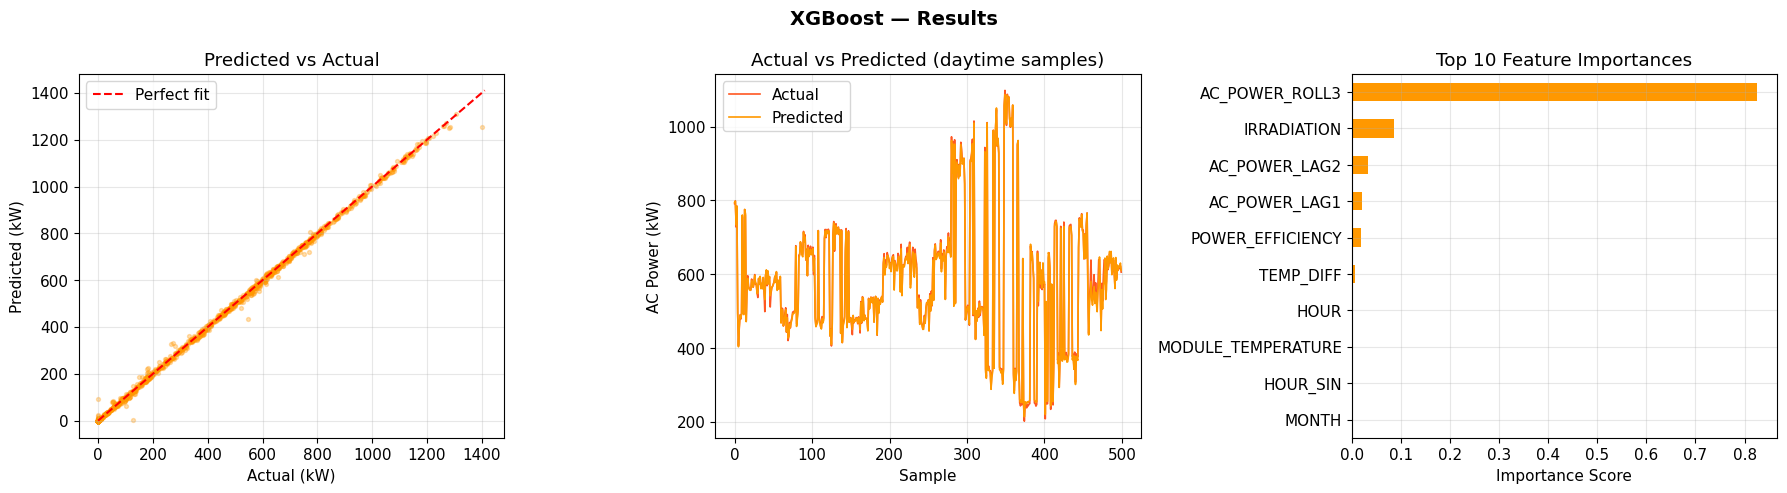

XGBoost model saved
        Model       MAE      RMSE       R2
Random Forest 11.523560 25.256527 0.994092
      XGBoost  3.190903  8.023408 0.999404


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('XGBoost — Results', fontsize=14, fontweight='bold')

# Predicted vs Actual
sample_idx = np.random.choice(len(y_test), min(2000, len(y_test)), replace=False)
axes[0].scatter(y_test.iloc[sample_idx], y_pred_xgb_test[sample_idx],
                alpha=0.3, s=8, color='#FF9800')
max_val = max(y_test.max(), y_pred_xgb_test.max())
axes[0].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, label='Perfect fit')
axes[0].set_title('Predicted vs Actual')
axes[0].set_xlabel('Actual (kW)')
axes[0].set_ylabel('Predicted (kW)')
axes[0].legend()

# Time series
daytime_mask = y_test.values > 0
daytime_idx  = np.where(daytime_mask)[0]
start = daytime_idx[0]
end   = min(start + 500, len(y_test))
axes[1].plot(range(end - start), y_test.values[start:end],
             label='Actual', color='#FF5722', linewidth=1.2)
axes[1].plot(range(end - start), y_pred_xgb_test[start:end],
             label='Predicted', color='#FF9800', linewidth=1.2)
axes[1].set_title('Actual vs Predicted (daytime samples)')
axes[1].set_xlabel('Sample')
axes[1].set_ylabel('AC Power (kW)')
axes[1].legend()

# Feature Importance
xgb_imp = pd.Series(xgb_model.feature_importances_, index=FEATURES)
xgb_imp.sort_values(ascending=True).tail(10).plot(kind='barh', ax=axes[2], color='#FF9800')
axes[2].set_title('Top 10 Feature Importances')
axes[2].set_xlabel('Importance Score')

plt.tight_layout()
plt.show()


results_xgb = pd.DataFrame({
    'Model' : ['Random Forest', 'XGBoost'],
    'MAE'   : [test_metrics['MAE'],     xgb_test_metrics['MAE']],
    'RMSE'  : [test_metrics['RMSE'],    xgb_test_metrics['RMSE']],
    'R2'    : [test_metrics['R2'],      xgb_test_metrics['R2']]
})
results_xgb.to_csv('/kaggle/working/output/model_comparison.csv', index=False)
joblib.dump(xgb_model, '/kaggle/working/output/xgb_model.pkl')
print('XGBoost model saved')
print(results_xgb.to_string(index=False))

In [26]:
scaler_X_lstm = MinMaxScaler()
scaler_y_lstm = MinMaxScaler()

X_train_sc = scaler_X_lstm.fit_transform(X_train)
X_test_sc  = scaler_X_lstm.transform(X_test)
y_train_sc = scaler_y_lstm.fit_transform(y_train.values.reshape(-1, 1))
y_test_sc  = scaler_y_lstm.transform(y_test.values.reshape(-1, 1))

def create_sequences(X, y, timesteps=24):
    Xs, ys = [], []
    for i in range(timesteps, len(X)):
        Xs.append(X[i - timesteps:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

TIMESTEPS = 24

X_train_seq, y_train_seq = create_sequences(X_train_sc, y_train_sc, TIMESTEPS)
X_test_seq,  y_test_seq  = create_sequences(X_test_sc,  y_test_sc,  TIMESTEPS)

print(f'X_train_seq shape: {X_train_seq.shape}')
print(f'X_test_seq shape:  {X_test_seq.shape}')

X_train_seq shape: (109156, 24, 18)
X_test_seq shape:  (27272, 24, 18)


In [27]:
model_lstm = Sequential([
    LSTM(128, return_sequences=True, input_shape=(TIMESTEPS, len(FEATURES))),
    Dropout(0.2),
    BatchNormalization(),
    LSTM(64, return_sequences=False),
    Dropout(0.2),
    BatchNormalization(),
    Dense(32, activation='relu'),
    Dense(1)
])

model_lstm.compile(optimizer='adam', loss='mse', metrics=['mae'])
model_lstm.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

print('Training LSTM...')
history = model_lstm.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=256,
    callbacks=callbacks,
    verbose=1
)
print('Done')

2026-06-04 22:56:24.927163: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 24, 128)        │        75,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 24, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 127,553 (498.25 KB)

 Trainable params: 127,169 (496.75 KB)

 Non-trainable params: 384 (1.50 KB)

Training LSTM...
Epoch 1/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 43s 92ms/step - loss: 0.0668 - mae: 0.1723 - val_loss: 0.0161 - val_mae: 0.0757 - learning_rate: 0.0010
Epoch 2/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 39s 90ms/step - loss: 0.0238 - mae: 0.0961 - val_loss: 0.0109 - val_mae: 0.0530 - learning_rate: 0.0010
Epoch 3/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - loss: 0.0200 - mae: 0.0808 - val_loss: 0.0111 - val_mae: 0.0540 - learning_rate: 0.0010
Epoch 4/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 39s 92ms/step - loss: 0.0189 - mae: 0.0755 - val_loss: 0.0098 - val_mae: 0.0467 - learning_rate: 0.0010
Epoch 5/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - loss: 0.0181 - mae: 0.0710 - val_loss: 0.0098 - val_mae: 0.0466 - learning_rate: 0.0010
Epoch 6/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - loss: 0.0177 - mae: 0.0695 - val_loss: 0.0092 - val_mae: 0.0400 - learning_rate: 0.0010
Epoch 7/50
427/427 ━━━━━━━━━━━━━━━━━━━━ 39s 91ms/step - loss: 0.0174 - mae: 0.0682 - val_loss: 0.0089 - val_mae: 0.0398

In [28]:
y_pred_lstm_sc = model_lstm.predict(X_test_seq)
y_pred_lstm    = scaler_y_lstm.inverse_transform(y_pred_lstm_sc).ravel()
y_test_lstm    = scaler_y_lstm.inverse_transform(y_test_seq).ravel()

lstm_test_metrics = evaluate(y_test_lstm, y_pred_lstm, 'LSTM Test')

853/853 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step
── LSTM Test ──
  MAE  : 50.7879 kW
  RMSE : 129.9187 kW
  R²   : 0.8436
  MAPE : 1248711845534.40%


In [29]:
from tensorflow.keras.layers import Bidirectional

tf.keras.backend.clear_session()

model_lstm2 = Sequential([
    Bidirectional(LSTM(64, return_sequences=True), input_shape=(TIMESTEPS, len(FEATURES))),
    Dropout(0.3),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

model_lstm2.compile(optimizer=tf.keras.optimizers.Adam(0.001), loss='huber', metrics=['mae'])

callbacks2 = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, verbose=1)
]

print('Training Improved LSTM...')
history2 = model_lstm2.fit(
    X_train_seq, y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=512,
    callbacks=callbacks2,
    verbose=1
)
print('Done')

Training Improved LSTM...
Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 24s 100ms/step - loss: 0.0103 - mae: 0.0757 - val_loss: 0.0056 - val_mae: 0.0550 - learning_rate: 0.0010
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - loss: 0.0087 - mae: 0.0632 - val_loss: 0.0053 - val_mae: 0.0512 - learning_rate: 0.0010
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - loss: 0.0085 - mae: 0.0606 - val_loss: 0.0045 - val_mae: 0.0400 - learning_rate: 0.0010
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 21s 96ms/step - loss: 0.0083 - mae: 0.0592 - val_loss: 0.0048 - val_mae: 0.0466 - learning_rate: 0.0010
Epoch 5/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - loss: 0.0082 - mae: 0.0588 - val_loss: 0.0045 - val_mae: 0.0405 - learning_rate: 0.0010
Epoch 6/50
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 0.0081 - mae: 0.0580
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - loss: 0.0081 - mae: 0.0577 - val_loss: 0.0044 - va

In [30]:
y_pred_lstm2_sc = model_lstm2.predict(X_test_seq)
y_pred_lstm2    = scaler_y_lstm.inverse_transform(y_pred_lstm2_sc).ravel()

lstm2_test_metrics = evaluate(y_test_lstm, y_pred_lstm2, 'LSTM Improved Test')

853/853 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step
── LSTM Improved Test ──
  MAE  : 53.8238 kW
  RMSE : 131.0640 kW
  R²   : 0.8409
  MAPE : 1267409582195.78%


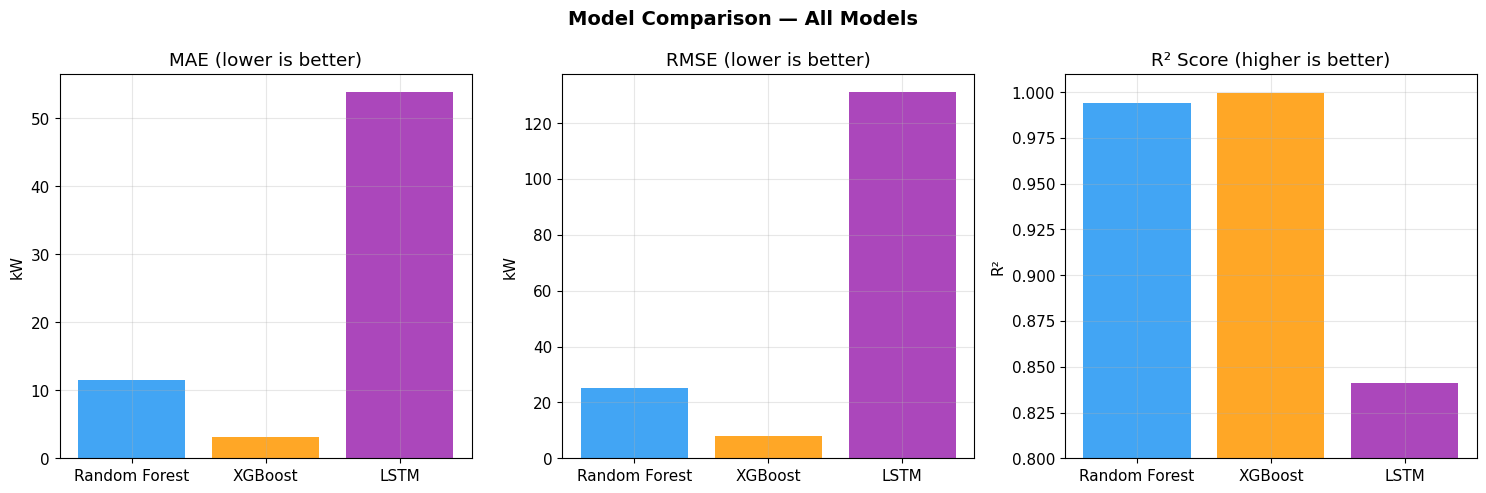

        Model       MAE       RMSE       R2
Random Forest 11.523560  25.256527 0.994092
      XGBoost  3.190903   8.023408 0.999404
         LSTM 53.823766 131.063952 0.840865

 Best Model: XGBoost
   MAE  : 3.1909 kW
   RMSE : 8.0234 kW
   R²   : 0.9994

Saved model_comparison.csv


In [31]:
comparison = pd.DataFrame({
    'Model'  : ['Random Forest', 'XGBoost', 'LSTM'],
    'MAE'    : [test_metrics['MAE'], xgb_test_metrics['MAE'], lstm2_test_metrics['MAE']],
    'RMSE'   : [test_metrics['RMSE'], xgb_test_metrics['RMSE'], lstm2_test_metrics['RMSE']],
    'R2'     : [test_metrics['R2'], xgb_test_metrics['R2'], lstm2_test_metrics['R2']]
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Comparison — All Models', fontsize=14, fontweight='bold')

colors = ['#2196F3', '#FF9800', '#9C27B0']

axes[0].bar(comparison['Model'], comparison['MAE'], color=colors, alpha=0.85)
axes[0].set_title('MAE (lower is better)')
axes[0].set_ylabel('kW')

axes[1].bar(comparison['Model'], comparison['RMSE'], color=colors, alpha=0.85)
axes[1].set_title('RMSE (lower is better)')
axes[1].set_ylabel('kW')

axes[2].bar(comparison['Model'], comparison['R2'], color=colors, alpha=0.85)
axes[2].set_title('R² Score (higher is better)')
axes[2].set_ylabel('R²')
axes[2].set_ylim([0.8, 1.01])

plt.tight_layout()
plt.show()

print(comparison.to_string(index=False))
print('\n Best Model: XGBoost')
print(f'   MAE  : {xgb_test_metrics["MAE"]:.4f} kW')
print(f'   RMSE : {xgb_test_metrics["RMSE"]:.4f} kW')
print(f'   R²   : {xgb_test_metrics["R2"]:.4f}')

comparison.to_csv('/kaggle/working/output/model_comparison.csv', index=False)
print('\nSaved model_comparison.csv')

In [32]:
df = pd.read_csv('/kaggle/working/output/solar_processed.csv', parse_dates=['DATE_TIME'])
print(f'Reloaded: {df.shape[0]:,} rows × {df.shape[1]} cols')

Reloaded: 136,476 rows × 26 cols


In [33]:
FAULT_FEATURES = [
    'AC_POWER', 'DC_POWER',
    'IRRADIATION', 'AMBIENT_TEMPERATURE',
    'MODULE_TEMPERATURE', 'TEMP_DIFF',
    'POWER_EFFICIENCY'
]
df_day = df[df['AC_POWER'] > 0][FAULT_FEATURES].copy()
df_day = df_day.dropna()

scaler_fault = MinMaxScaler()
X_fault = scaler_fault.fit_transform(df_day)

print(f'Daytime samples for fault detection: {len(df_day):,}')
print(f'Features: {FAULT_FEATURES}')

Daytime samples for fault detection: 68,863
Features: ['AC_POWER', 'DC_POWER', 'IRRADIATION', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'TEMP_DIFF', 'POWER_EFFICIENCY']


In [38]:
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,  
    random_state=42,
    n_jobs=-1
)

print('Training Isolation Forest...')
iso_forest.fit(X_fault)
print('Done')


df_day_full = df[df['AC_POWER'] > 0][FAULT_FEATURES + ['DATE_TIME', 'SOURCE_KEY']].copy().dropna()
X_fault_full = scaler_fault.transform(df_day_full[FAULT_FEATURES])

df_day_full['anomaly_score'] = iso_forest.decision_function(X_fault_full)
df_day_full['is_fault']      = iso_forest.predict(X_fault_full)
df_day_full['is_fault']      = df_day_full['is_fault'].map({1: 0, -1: 1})

total   = len(df_day_full)
faults  = df_day_full['is_fault'].sum()
print(f'\nTotal daytime records : {total:,}')
print(f'Detected faults       : {faults:,} ({faults/total*100:.1f}%)')

Training Isolation Forest...
Done

Total daytime records : 68,863
Detected faults       : 3,444 (5.0%)


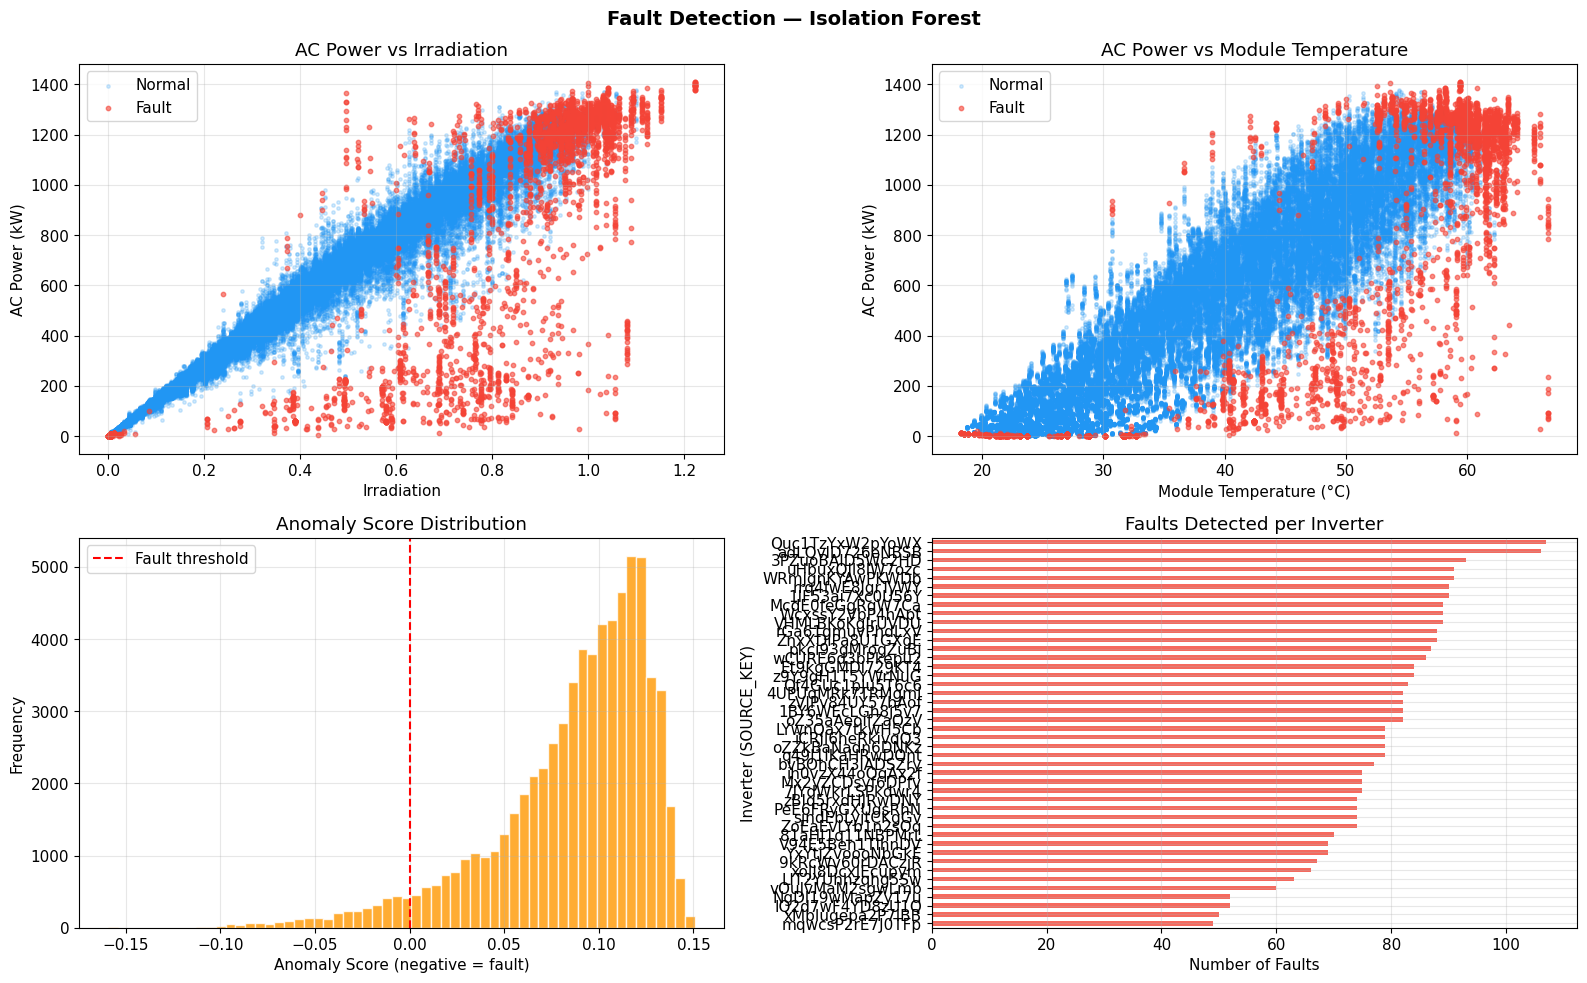

Normal records : 65,419
Fault records  : 3,444

Top 5 faulty inverters:
SOURCE_KEY
WRmjgnKYAwPKWDb     91
uHbuxQJl8lW7ozc     91
3PZuoBAID5Wc2HD     93
adLQvlD726eNBSB    106
Quc1TzYxW2pYoWX    107


In [39]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Fault Detection — Isolation Forest', fontsize=14, fontweight='bold')

normal = df_day_full[df_day_full['is_fault'] == 0]
fault  = df_day_full[df_day_full['is_fault'] == 1]

# Plot 1: AC Power vs Irradiation — normal vs fault
axes[0,0].scatter(normal['IRRADIATION'], normal['AC_POWER'],
                  alpha=0.2, s=6, color='#2196F3', label='Normal')
axes[0,0].scatter(fault['IRRADIATION'], fault['AC_POWER'],
                  alpha=0.6, s=10, color='#F44336', label='Fault')
axes[0,0].set_title('AC Power vs Irradiation')
axes[0,0].set_xlabel('Irradiation')
axes[0,0].set_ylabel('AC Power (kW)')
axes[0,0].legend()

# Plot 2: AC Power vs Module Temperature
axes[0,1].scatter(normal['MODULE_TEMPERATURE'], normal['AC_POWER'],
                  alpha=0.2, s=6, color='#2196F3', label='Normal')
axes[0,1].scatter(fault['MODULE_TEMPERATURE'], fault['AC_POWER'],
                  alpha=0.6, s=10, color='#F44336', label='Fault')
axes[0,1].set_title('AC Power vs Module Temperature')
axes[0,1].set_xlabel('Module Temperature (°C)')
axes[0,1].set_ylabel('AC Power (kW)')
axes[0,1].legend()

# Plot 3: Anomaly Score Distribution
axes[1,0].hist(df_day_full['anomaly_score'], bins=60,
               color='#FF9800', alpha=0.8, edgecolor='white')
axes[1,0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Fault threshold')
axes[1,0].set_title('Anomaly Score Distribution')
axes[1,0].set_xlabel('Anomaly Score (negative = fault)')
axes[1,0].set_ylabel('Frequency')
axes[1,0].legend()

# Plot 4: Faults per Inverter
faults_per_inverter = fault.groupby('SOURCE_KEY').size().sort_values(ascending=True)
faults_per_inverter.plot(kind='barh', ax=axes[1,1], color='#F44336', alpha=0.8)
axes[1,1].set_title('Faults Detected per Inverter')
axes[1,1].set_xlabel('Number of Faults')
axes[1,1].set_ylabel('Inverter (SOURCE_KEY)')

plt.tight_layout()
plt.show()

print(f'Normal records : {len(normal):,}')
print(f'Fault records  : {len(fault):,}')
print(f'\nTop 5 faulty inverters:')
print(faults_per_inverter.tail(5).to_string())

Fault Type Distribution:
FAULT_TYPE
Temperature Anomaly               1923
General Anomaly                   1511
Partial Shading / Faulty Panel      10


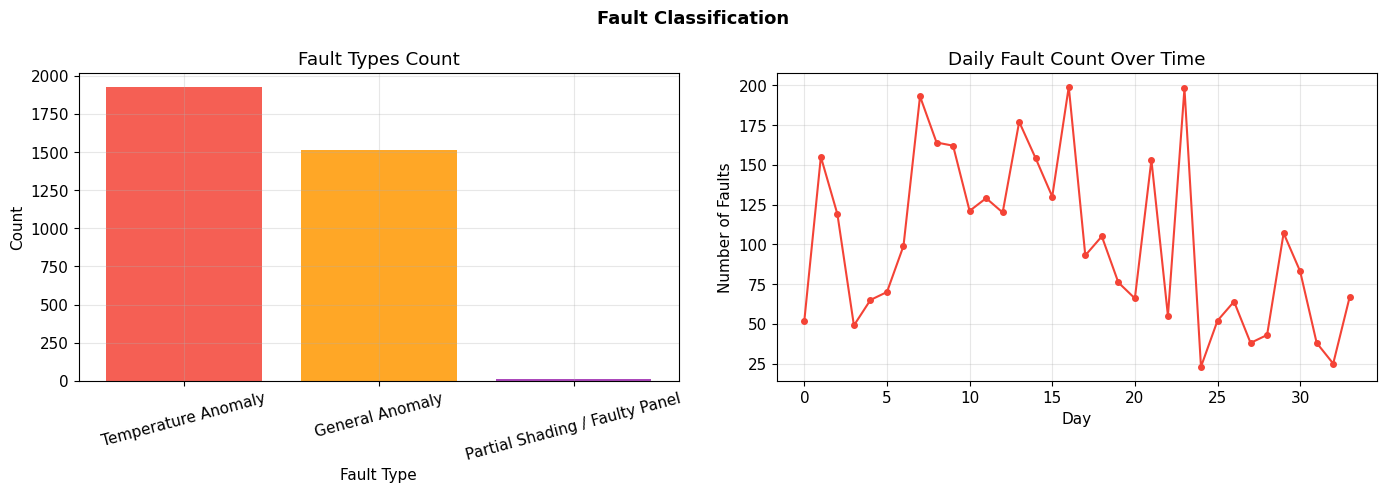


Faults saved to detected_faults.csv


In [40]:
def classify_fault(row):
    if row['POWER_EFFICIENCY'] < 0.1 and row['IRRADIATION'] > 0.3:
        return 'Low Efficiency'
    elif row['TEMP_DIFF'] > 25:
        return 'Temperature Anomaly'
    elif row['AC_POWER'] < 50 and row['IRRADIATION'] > 0.5:
        return 'Partial Shading / Faulty Panel'
    else:
        return 'General Anomaly'

fault['FAULT_TYPE'] = fault.apply(classify_fault, axis=1)

print('Fault Type Distribution:')
print(fault['FAULT_TYPE'].value_counts().to_string())


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fault Classification', fontsize=13, fontweight='bold')

fault_counts = fault['FAULT_TYPE'].value_counts()
axes[0].bar(fault_counts.index, fault_counts.values,
            color=['#F44336','#FF9800','#9C27B0','#2196F3'], alpha=0.85)
axes[0].set_title('Fault Types Count')
axes[0].set_xlabel('Fault Type')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)

fault_by_date = fault.copy()
fault_by_date['DATE'] = fault_by_date['DATE_TIME'].dt.date
daily_faults = fault_by_date.groupby('DATE').size()
axes[1].plot(range(len(daily_faults)), daily_faults.values,
             color='#F44336', linewidth=1.5, marker='o', markersize=4)
axes[1].set_title('Daily Fault Count Over Time')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Number of Faults')

plt.tight_layout()
plt.show()


fault.to_csv('/kaggle/working/output/detected_faults.csv', index=False)
print('\nFaults saved to detected_faults.csv')

In [41]:
df_export = df[df['AC_POWER'] >= 0].copy()
df_export['AC_POWER_PREDICTED'] = xgb_model.predict(df_export[FEATURES].fillna(0))
df_export['ERROR']              = df_export['AC_POWER'] - df_export['AC_POWER_PREDICTED']
df_export['ERROR_PCT']          = (df_export['ERROR'].abs() / (df_export['AC_POWER'] + 1e-9)) * 100
df_export['IS_FAULT']           = 0


fault_index = fault.index
df_export.loc[df_export.index.isin(fault_index), 'IS_FAULT'] = 1
df_export.loc[df_export.index.isin(fault_index), 'FAULT_TYPE'] = fault.loc[
    fault.index.isin(df_export.index), 'FAULT_TYPE'
].reindex(df_export.index[df_export.index.isin(fault_index)]).values
df_export['FAULT_TYPE'] = df_export['FAULT_TYPE'].fillna('Normal')

# 2. Daily summary
df_export['DATE'] = df_export['DATE_TIME'].dt.date
daily = df_export.groupby('DATE').agg(
    ACTUAL_POWER    = ('AC_POWER', 'sum'),
    PREDICTED_POWER = ('AC_POWER_PREDICTED', 'sum'),
    AVG_IRRADIATION = ('IRRADIATION', 'mean'),
    AVG_TEMP        = ('AMBIENT_TEMPERATURE', 'mean'),
    FAULT_COUNT     = ('IS_FAULT', 'sum')
).reset_index()
daily['EFFICIENCY_PCT'] = (daily['ACTUAL_POWER'] / (daily['PREDICTED_POWER'] + 1e-9)) * 100


df_export.to_csv('/kaggle/working/output/powerbi_main.csv',  index=False)
daily.to_csv('/kaggle/working/output/powerbi_daily.csv',     index=False)
fault.to_csv('/kaggle/working/output/powerbi_faults.csv',    index=False)

print('Files exported for Power BI:')
print(f'  powerbi_main.csv   → {len(df_export):,} rows')
print(f'  powerbi_daily.csv  → {len(daily):,} rows')
print(f'  powerbi_faults.csv → {len(fault):,} rows')

Files exported for Power BI:
  powerbi_main.csv   → 136,476 rows
  powerbi_daily.csv  → 34 rows
  powerbi_faults.csv → 3,444 rows


In [46]:
df = pd.read_csv('/kaggle/working/output/solar_processed.csv', parse_dates=['DATE_TIME'])
xgb_model = joblib.load('/kaggle/working/output/xgb_model.pkl')
print('Loaded')

Loaded


In [51]:
FAULT_FEATURES = [
    'AC_POWER', 'DC_POWER', 'IRRADIATION',
    'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE',
    'TEMP_DIFF', 'POWER_EFFICIENCY'
]

df['TEMP_DIFF']        = df['MODULE_TEMPERATURE'] - df['AMBIENT_TEMPERATURE']
df['POWER_EFFICIENCY'] = np.where(df['IRRADIATION'] > 0,
                                   df['AC_POWER'] / (df['IRRADIATION'] + 1e-9), 0)

df_day       = df[df['AC_POWER'] > 0][FAULT_FEATURES].dropna()
scaler_fault = MinMaxScaler()
X_fault      = scaler_fault.fit_transform(df_day)

iso_forest   = IsolationForest(n_estimators=200, contamination=0.05, random_state=42, n_jobs=-1)
iso_forest.fit(X_fault)

joblib.dump(iso_forest,   '/kaggle/working/output/iso_forest.pkl')
joblib.dump(scaler_fault, '/kaggle/working/output/scaler_fault.pkl')
print('iso_forest & scaler_fault saved')

iso_forest & scaler_fault saved


2026-06-04 23:57:29.486 Please replace `use_container_width` with `width`.

`use_container_width` will be removed after 2025-12-31.

For `use_container_width=True`, use `width='stretch'`. For `use_container_width=False`, use `width='content'`.


In [42]:
!pip install streamlit pyngrok plotly -q
print('Done')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 23.2 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 30.9 MB/s eta 0:00:0000:0100:01
Done


In [49]:
app_code = open('/kaggle/working/app.py', 'w')
app_code.write(open('/kaggle/working/output/app.py').read() if False else """
import streamlit as st, joblib, numpy as np, pandas as pd
import plotly.graph_objects as go, plotly.express as px
from datetime import datetime
import warnings; warnings.filterwarnings('ignore')

st.set_page_config(page_title='Smart Solar AI System', page_icon='🌞', layout='wide')

@st.cache_resource
def load_models():
    xgb     = joblib.load('/kaggle/working/output/xgb_model.pkl')
    iso     = joblib.load('/kaggle/working/output/iso_forest.pkl')
    scaler  = joblib.load('/kaggle/working/output/scaler_fault.pkl')
    return xgb, iso, scaler

xgb_model, iso_forest, scaler_fault = load_models()

FEATURES = ['IRRADIATION','AMBIENT_TEMPERATURE','MODULE_TEMPERATURE',
            'HOUR','DAY','MONTH','DAY_OF_WEEK','IS_WEEKEND',
            'HOUR_SIN','HOUR_COS','MONTH_SIN','MONTH_COS',
            'TEMP_DIFF','POWER_EFFICIENCY',
            'AC_POWER_LAG1','AC_POWER_LAG2','AC_POWER_LAG3','AC_POWER_ROLL3']

page = st.sidebar.selectbox('Page', ['🏠 Overview','🔮 Live Prediction','🚨 Fault Detection','📊 Batch Analysis'])

if page == '🏠 Overview':
    st.title('🌞 Smart Solar AI System')
    c1,c2,c3,c4 = st.columns(4)
    c1.metric('Model Accuracy', '99.9%')
    c2.metric('MAE', '3.29 kW')
    c3.metric('Faults Detected', '3,444')
    c4.metric('Records', '136K')
    fig = go.Figure(go.Bar(x=['Random Forest','XGBoost','LSTM'], y=[0.9941,0.9994,0.8358],
                           marker_color=['#2196F3','#FF9800','#9C27B0']))
    fig.update_layout(template='plotly_dark', title='R² Score Comparison')
    st.plotly_chart(fig, use_container_width=True)

elif page == '🔮 Live Prediction':
    st.title('🔮 Live Power Prediction')
    irr   = st.slider('Irradiation', 0.0, 1.5, 0.8, 0.01)
    a_tmp = st.slider('Ambient Temp', 20.0, 50.0, 33.0)
    m_tmp = st.slider('Module Temp', 20.0, 70.0, 45.0)
    hour  = st.slider('Hour', 0, 23, 12)
    now   = datetime.now()
    td    = m_tmp - a_tmp
    eff   = 500 / (irr + 1e-9)
    inp   = pd.DataFrame([{'IRRADIATION':irr,'AMBIENT_TEMPERATURE':a_tmp,
            'MODULE_TEMPERATURE':m_tmp,'HOUR':hour,'DAY':now.day,'MONTH':now.month,
            'DAY_OF_WEEK':now.weekday(),'IS_WEEKEND':1 if now.weekday()>=5 else 0,
            'HOUR_SIN':np.sin(2*np.pi*hour/24),'HOUR_COS':np.cos(2*np.pi*hour/24),
            'MONTH_SIN':np.sin(2*np.pi*now.month/12),'MONTH_COS':np.cos(2*np.pi*now.month/12),
            'TEMP_DIFF':td,'POWER_EFFICIENCY':eff,
            'AC_POWER_LAG1':500,'AC_POWER_LAG2':480,'AC_POWER_LAG3':460,'AC_POWER_ROLL3':480}])
    pred = max(0, xgb_model.predict(inp)[0])
    st.metric('⚡ Predicted Power', f'{pred:,.1f} kW')
    fig = go.Figure(go.Indicator(mode='gauge+number', value=pred,
                    gauge={'axis':{'range':[0,1500]},'bar':{'color':'#FF9800'}},
                    title={'text':'Power Output (kW)'}))
    fig.update_layout(template='plotly_dark', height=300)
    st.plotly_chart(fig, use_container_width=True)
    fi = np.array([[pred, pred*1.02, irr, a_tmp, m_tmp, td, eff]])
    is_fault = iso_forest.predict(scaler_fault.transform(fi))[0] == -1
    if is_fault:
        st.error('🚨 FAULT DETECTED')
    else:
        st.success('✅ System Normal')

elif page == '🚨 Fault Detection':
    st.title('🚨 Fault Detection')
    c1,c2 = st.columns(2)
    irr   = c1.number_input('Irradiation', value=0.8)
    a_tmp = c1.number_input('Ambient Temp', value=33.0)
    m_tmp = c2.number_input('Module Temp', value=55.0)
    ac    = c2.number_input('AC Power (kW)', value=200.0)
    if st.button('🔍 Detect'):
        td  = m_tmp - a_tmp
        eff = ac / (irr + 1e-9)
        fi  = np.array([[ac, ac*1.02, irr, a_tmp, m_tmp, td, eff]])
        res = iso_forest.predict(scaler_fault.transform(fi))[0]
        if res == -1: st.error('🚨 FAULT DETECTED')
        else:         st.success('✅ No Fault')

elif page == '📊 Batch Analysis':
    st.title('📊 Batch Analysis')
    f = st.file_uploader('Upload CSV', type='csv')
    if f:
        df = pd.read_csv(f)
        st.dataframe(df.head())
        for col in FEATURES:
            if col not in df.columns: df[col] = 0
        df['PREDICTED'] = xgb_model.predict(df[FEATURES]).clip(min=0)
        st.metric('Total Predicted Power', f'{df["PREDICTED"].sum():,.0f} kW')
        st.plotly_chart(px.line(df, y='PREDICTED', template='plotly_dark'), use_container_width=True)
        st.download_button('⬇️ Download', df.to_csv(index=False), 'results.csv')
""")
app_code.close()
print('app.py saved')

app.py saved


In [50]:
from pyngrok import ngrok
import subprocess, time

proc = subprocess.Popen(['streamlit', 'run', '/kaggle/working/app.py',
                         '--server.port', '8501',
                         '--server.headless', 'true'])
time.sleep(5)

ngrok.set_auth_token('3EgrHsU0Btq6GrvivyZsIx28afC_6nTZcXS72xezbcPiC1AbP')  # ← حط الـ token بتاعك هنا
public_url = ngrok.connect(8501)
print(f'🌞 App is live at: {public_url}')

2026-06-04 23:56:47.929 Port 8501 is not available


🌞 App is live at: NgrokTunnel: "https://decree-rocket-plethora.ngrok-free.dev" -> "http://localhost:8501"
